In [1]:
import os
import numpy as np
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping


In [2]:
def load_images_from_folder(folder_path):
    images = []
    labels = []
    classes = os.listdir(folder_path)
    for class_name in classes:
        class_path = os.path.join(folder_path, class_name)
        if not os.path.isdir(class_path):
            continue
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)
            try:
                # Ensure all images are converted to RGB and resized to 128x128
                image = Image.open(image_path).convert('RGB').resize((128, 128))
                images.append(np.array(image))
                labels.append(class_name)
            except (PermissionError, Exception) as e:
                print(f"Error: {e}. Skipping file: {image_path}")
    if len(images) > 0:
        return np.stack(images), np.array(labels)
    else:
        raise ValueError("No valid images found in the folder: " + folder_path)


In [3]:
train_path = "D:/university/cse400(A,B,C)/Dataset/datasetM/train"
test_path = "D:/university/cse400(A,B,C)/Dataset/datasetM/test"


In [4]:
X_train, y_train = load_images_from_folder(train_path)
X_test, y_test = load_images_from_folder(test_path)


In [5]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)


In [6]:
X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0


In [7]:
label_encoder = LabelEncoder()
y_train = to_categorical(label_encoder.fit_transform(y_train))
y_val = to_categorical(label_encoder.transform(y_val))
y_test = to_categorical(label_encoder.transform(y_test))


In [8]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)


In [9]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.5),
    Dense(len(label_encoder.classes_), activation='softmax')
])


In [10]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])


In [11]:
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)


In [12]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=200,
    validation_data=(X_val, y_val),
    callbacks=[lr_scheduler, early_stopping]
)


Epoch 1/200
316/316 [==============================] - 102s 270ms/step - loss: 6.1110 - accuracy: 0.3864 - val_loss: 6.2513 - val_accuracy: 0.1880 - lr: 1.0000e-04
Epoch 2/200
316/316 [==============================] - 72s 228ms/step - loss: 4.5573 - accuracy: 0.5750 - val_loss: 5.4940 - val_accuracy: 0.1002 - lr: 1.0000e-04
Epoch 3/200
316/316 [==============================] - 1213s 4s/step - loss: 3.5035 - accuracy: 0.6647 - val_loss: 4.0582 - val_accuracy: 0.3880 - lr: 1.0000e-04
Epoch 4/200
316/316 [==============================] - 71s 226ms/step - loss: 2.7351 - accuracy: 0.7246 - val_loss: 2.6703 - val_accuracy: 0.6744 - lr: 1.0000e-04
Epoch 5/200
316/316 [==============================] - 72s 226ms/step - loss: 2.1637 - accuracy: 0.7632 - val_loss: 2.3427 - val_accuracy: 0.6677 - lr: 1.0000e-04
Epoch 6/200
316/316 [==============================] - 70s 221ms/step - loss: 1.7348 - accuracy: 0.7939 - val_loss: 1.8683 - val_accuracy: 0.7286 - lr: 1.0000e-04
Epoch 7/200
316/316 [=

In [13]:
# Save the model to an H5 file
model.save('lung_cancer_classification_model.h5')



In [14]:
batch_size = 32
num_batches = len(X_val) // batch_size + 1
y_val_preds = []

for i in range(num_batches):
    X_batch = X_val[i * batch_size:(i + 1) * batch_size]
    if len(X_batch) > 0:
        y_batch_pred = model.predict(X_batch)
        y_val_preds.append(y_batch_pred)

y_val_pred = np.argmax(np.vstack(y_val_preds), axis=1)
y_val_true = np.argmax(y_val, axis=1)


1/1 [==============================] - 0s 500ms/step


In [15]:
print("Validation Classification Report:")
print(classification_report(y_val_true, y_val_pred, target_names=label_encoder.classes_))


Validation Classification Report:
                                                                    precision    recall  f1-score   support

                                           Acne and Rosacea Photos       0.86      0.79      0.82       218
Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions       0.81      0.80      0.80       339
                                                      Athlete-foot       1.00      0.84      0.91        25
                                          Atopic Dermatitis Photos       0.90      0.67      0.77       278
                                            Bullous Disease Photos       0.94      0.79      0.86       192
                                                        Chickenpox       1.00      0.92      0.96        25
                                                     Eczema Photos       0.76      0.89      0.82       502
                                  Herpes HPV and other STDs Photos       0.66      0.67      0.67    

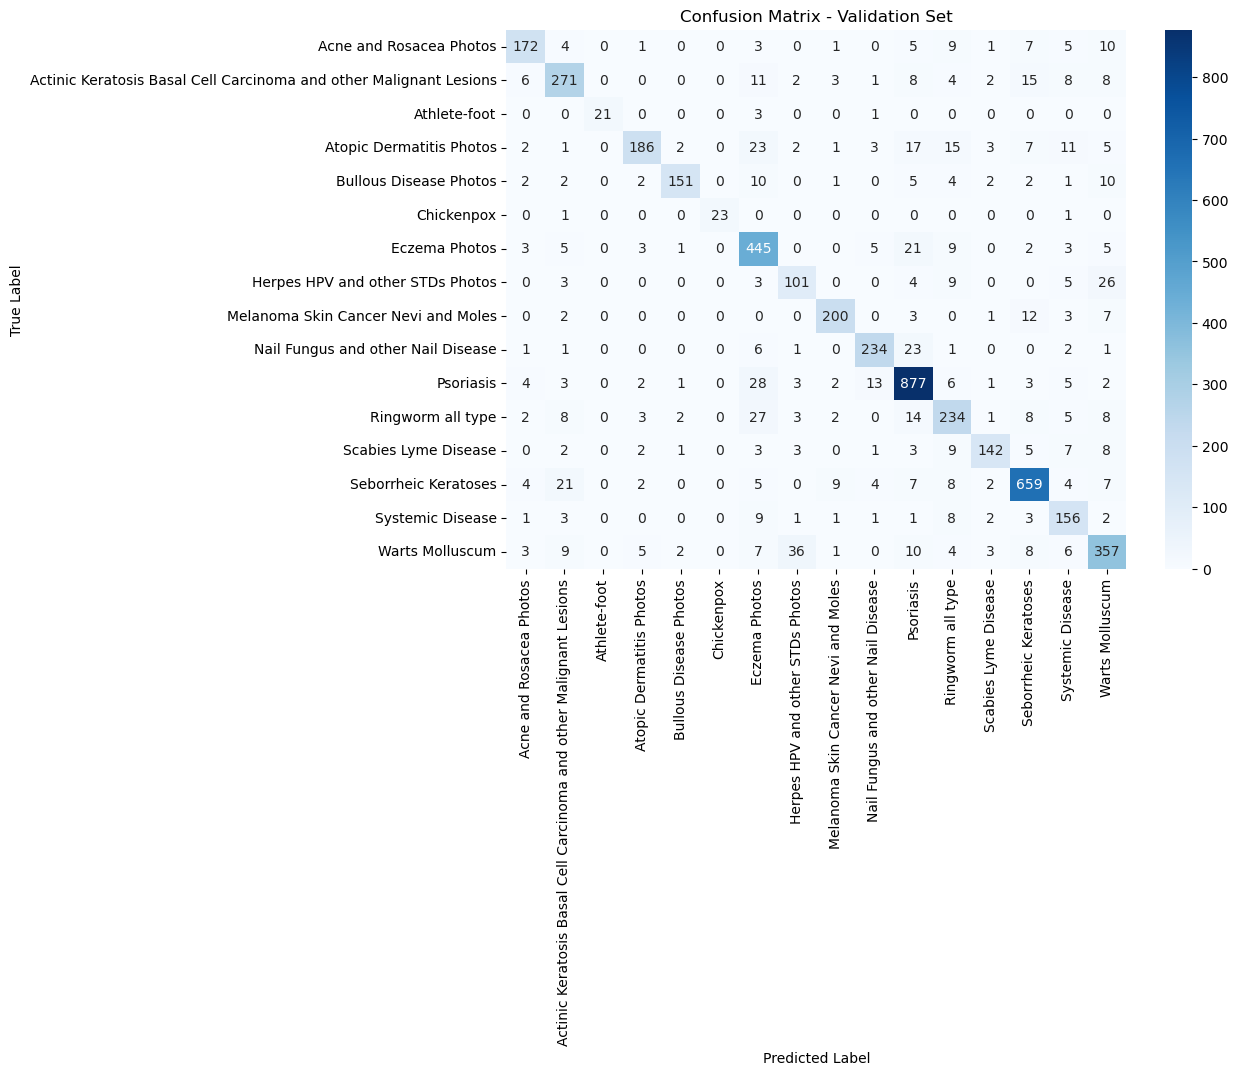

In [16]:
conf_matrix_val = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix_val, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Validation Set')
plt.show()


In [17]:
batch_size = 32
num_batches = len(X_test) // batch_size + 1
y_test_preds = []

for i in range(num_batches):
    X_batch = X_test[i * batch_size:(i + 1) * batch_size]
    if len(X_batch) > 0:
        y_batch_pred = model.predict(X_batch)
        y_test_preds.append(y_batch_pred)

# Combine predictions from all batches
y_test_pred = np.argmax(np.vstack(y_test_preds), axis=1)

# Get the true labels for the test set
y_test_true = np.argmax(y_test, axis=1)

# Print the classification report for the test set
print("Test Classification Report:")
print(classification_report(y_test_true, y_test_pred, target_names=label_encoder.classes_))


1/1 [==============================] - 0s 104ms/step
Test Classification Report:
                                                                    precision    recall  f1-score   support

                                           Acne and Rosacea Photos       0.87      0.62      0.72       961
Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions       0.73      0.86      0.79       769
                                                      Athlete-foot       0.59      0.91      0.72        32
                                          Atopic Dermatitis Photos       0.54      0.60      0.57      1509
                                            Bullous Disease Photos       0.81      0.86      0.83       610
                                                        Chickenpox       0.85      1.00      0.92        34
                                                     Eczema Photos       0.68      0.88      0.77      1683
                                  Herpes HPV and other

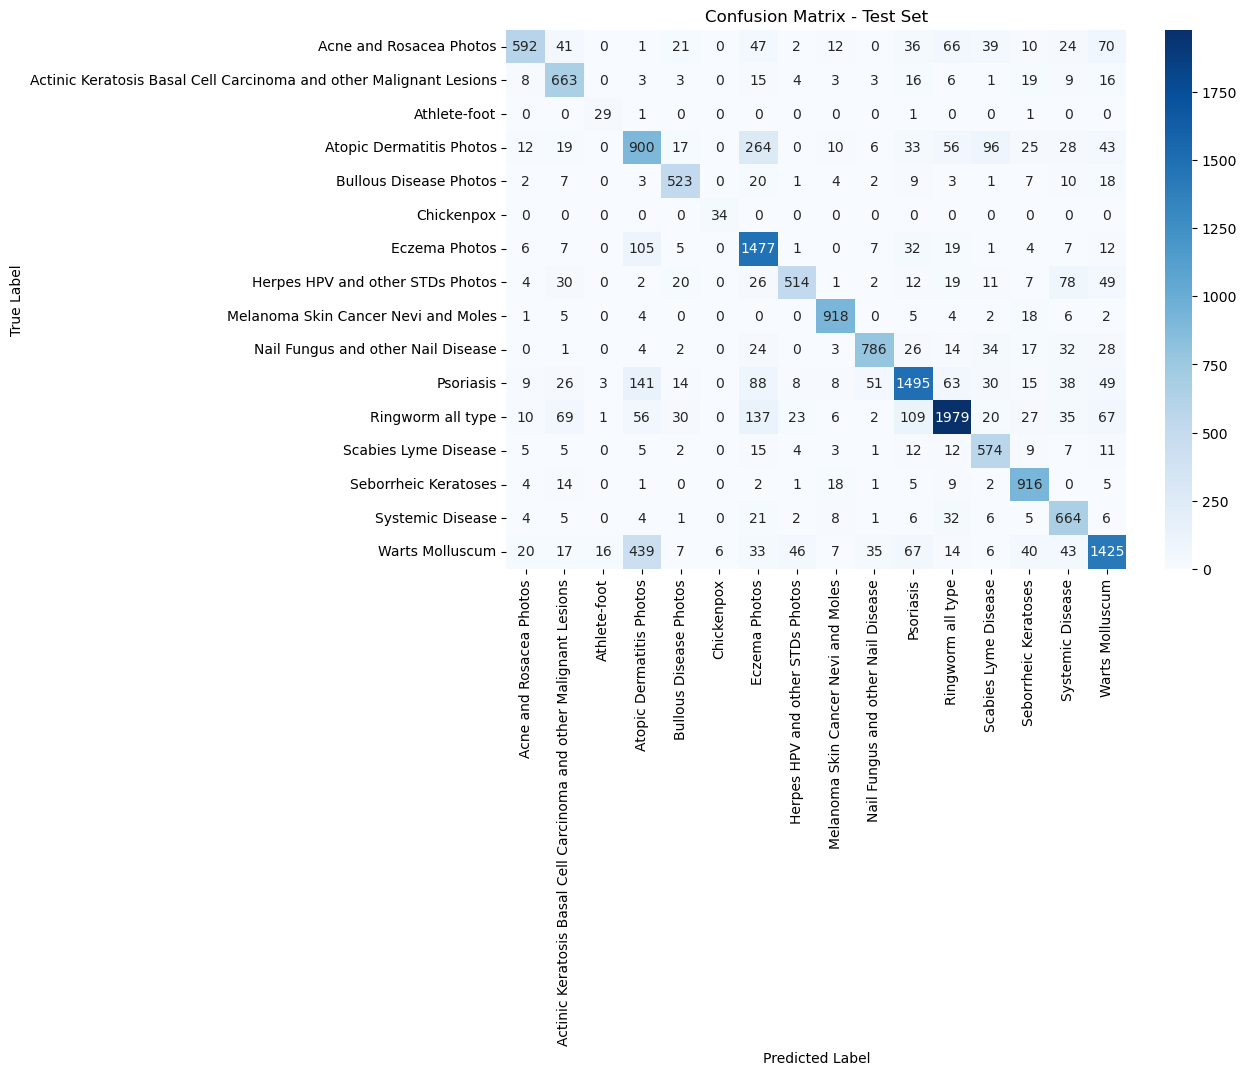

In [18]:
conf_matrix_test = confusion_matrix(y_test_true, y_test_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Test Set')
plt.show()


In [19]:
batch_size = 32
num_batches = len(X_test) // batch_size + 1
total_loss = 0
total_accuracy = 0
num_samples = 0

for i in range(num_batches):
    X_batch = X_test[i * batch_size:(i + 1) * batch_size]
    y_batch = y_test[i * batch_size:(i + 1) * batch_size]
    if len(X_batch) > 0:
        batch_loss, batch_accuracy = model.evaluate(X_batch, y_batch, verbose=0)
        total_loss += batch_loss * len(X_batch)
        total_accuracy += batch_accuracy * len(X_batch)
        num_samples += len(X_batch)

# Compute average loss and accuracy
test_loss = total_loss / num_samples
test_accuracy = total_accuracy / num_samples

print(f"Test loss: {test_loss}")
print(f"Test accuracy: {test_accuracy}")


Test loss: 1.3222032804302173
Test accuracy: 0.7687353963810352


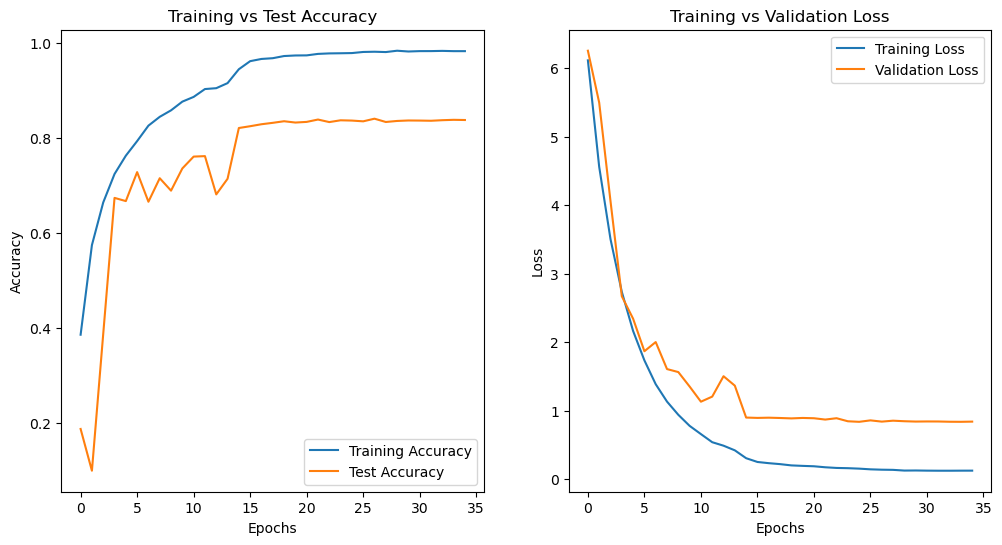

In [20]:
plt.figure(figsize=(12, 6))

# Plot training & validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Training vs Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()
